# Customer Decision Hierarchy Gallery

The customer decision hierarchy renders a dendrogram of product substitutability, derived from co-purchase patterns. Products that share customer bases cluster on the same branch: those are the SKUs customers treat as interchangeable variations of the same need. Products on separate branches fill genuinely different needs.

Customer decision hierarchies excel at:
- **Range rationalization**: identify SKUs within the same cluster that are safe candidates for delisting
- **Private label strategy**: position PL alongside national brands customers already treat as variations of the same need
- **New product cannibalization**: predict which existing SKUs a new launch will draw volume from
- **Space productivity**: allocate facings based on whether a product fills a unique need or duplicates one

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from openretailscience.analysis.customer_decision_hierarchy import CustomerDecisionHierarchy

In [ ]:
# Hand-crafted yogurt assortment dataset.
# 9 SKUs grouped into 3 substitution clusters (Greek, Regular, Kids).
# Two small crossover segments create weak bridges between clusters so the
# dendrogram shows graded distances rather than three perfectly separated branches.
#
# Each customer buys their preferred SKUs in separate transactions, so
# `exclude_same_transaction_products` (the default) leaves every pair intact.

_SEGMENTS = [
    # (n_customers, [products bought by every customer in this segment])
    (30, ["Greek Vanilla", "Greek Strawberry", "Greek Honey"]),
    (30, ["Regular Vanilla", "Regular Strawberry", "Regular Peach"]),
    (25, ["Kids Squeeze Pouch", "Kids Yogurt Tube", "Kids Mini Cup"]),
    # Crossover: 10 health-conscious shoppers who pick up the vanilla in both formats
    (10, ["Greek Vanilla", "Regular Vanilla"]),
    # Crossover: 10 family households who add a kids cup alongside Regular Strawberry
    (10, ["Regular Strawberry", "Kids Mini Cup"]),
]

_rows = []
_next_customer_id = 1_000
_next_transaction_id = 5_000
for n_customers, products in _SEGMENTS:
    customer_ids = np.arange(_next_customer_id, _next_customer_id + n_customers)
    _next_customer_id += n_customers
    # One row per (customer, product) pair, each in its own transaction.
    customer_col = np.repeat(customer_ids, len(products))
    product_col = np.tile(products, n_customers)
    transaction_col = np.arange(_next_transaction_id, _next_transaction_id + customer_col.size)
    _next_transaction_id += customer_col.size
    _rows.append(
        pd.DataFrame(
            {
                "customer_id": customer_col,
                "transaction_id": transaction_col,
                "product_name": product_col,
            }
        )
    )

yogurt_transactions = pd.concat(_rows, ignore_index=True)

## Default Vertical Dendrogram

The simplest call: build the analysis from a transactions DataFrame and call `plot()`. The default `orientation="top"` grows the tree downward with leaves along the bottom. Branch height encodes substitution distance: tightly co-purchased SKUs join close to the bottom (they're substitutes), while branches that join near the top fill genuinely different needs.

---

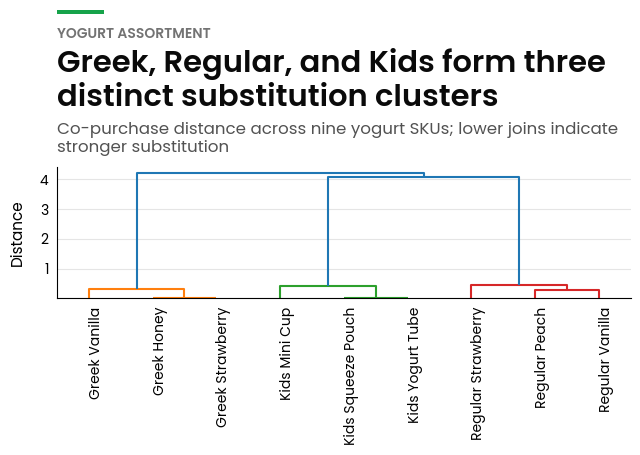

In [ ]:
cdh = CustomerDecisionHierarchy(yogurt_transactions, product_col="product_name")

cdh.plot(
    eyebrow="Yogurt assortment",
    title="Greek, Regular, and Kids form three distinct substitution clusters",
    subtitle="Co-purchase distance across nine yogurt SKUs; lower joins indicate stronger substitution",
)
plt.show()

## Horizontal Orientation

Pass `orientation="right"` for a horizontal layout. Leaves sit on the left, distance grows rightward. This is the most readable shape when product names are long, since labels never need to be rotated. The function passes the `orientation` keyword straight through to scipy's `dendrogram`; `"left"`, `"top"`, and `"bottom"` work the same way.

---

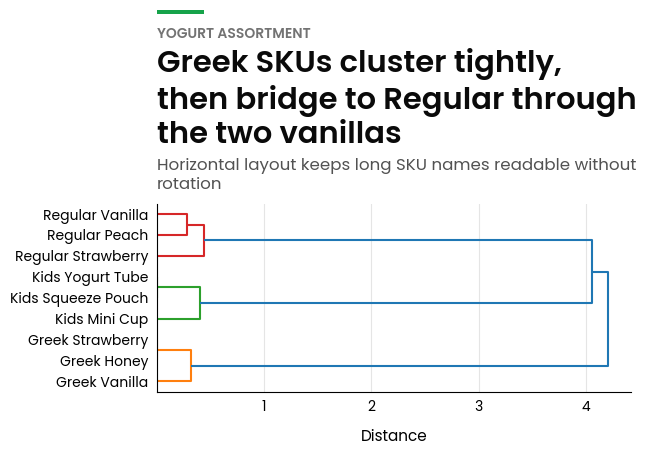

In [ ]:
cdh.plot(
    orientation="right",
    eyebrow="Yogurt assortment",
    title="Greek SKUs cluster tightly, then bridge to Regular through the two vanillas",
    subtitle="Horizontal layout keeps long SKU names readable without rotation",
)
plt.show()

## Adding a Source Annotation

Pass `source_text` to drop a small attribution line at the bottom of the chart. Useful when the image will be exported into a deck or report and the audience needs to know which dataset produced it. Combine with the `eyebrow`, `title`, and `subtitle` block to ship a chart that reads as a finished artefact rather than an exploratory plot.

---

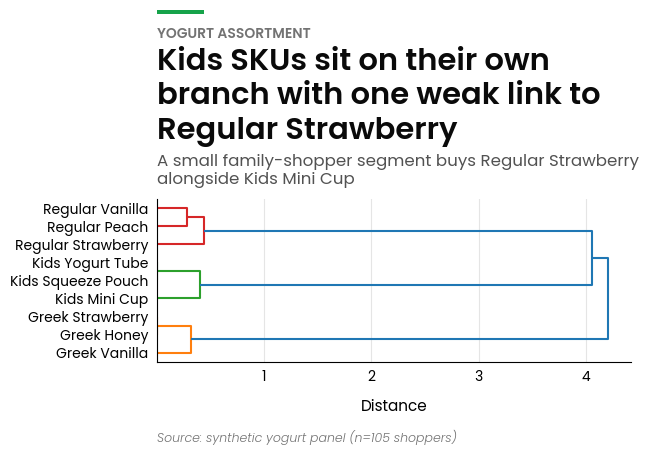

In [ ]:
cdh.plot(
    orientation="right",
    eyebrow="Yogurt assortment",
    title="Kids SKUs sit on their own branch with one weak link to Regular Strawberry",
    subtitle="A small family-shopper segment buys Regular Strawberry alongside Kids Mini Cup",
    source_text="Source: synthetic yogurt panel (n=105 shoppers)",
)
plt.show()